In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXEFENjk4LWdlbmVyYXRpdmUtYWktZm9yLUJBXE0x'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\zipimport.py": 1744145814.0, "C:\\Program Files\\Python312\\Lib\\codecs.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\aliases.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\__init__.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\utf_8.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\encodings\\cp1252.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\abc.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\io.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\stat.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\_collections_abc.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\genericpath.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\ntpath.py": 1744145812.0, "C:\\Program Files\\Python312\\Lib\\o

In [2]:
def read_xy_data(filename: str) -> tuple[list[str], list[int]]:
    x_data = []
    y_data = []
    with open(filename, 'r') as f:
        for line in f:
            label, text = line.strip().split(' ||| ')
            x_data.append(text)
            y_data.append(int(label))
    return x_data, y_data


x_train, y_train = read_xy_data('./data/sentiment-treebank/train.txt')
x_test, y_test = read_xy_data('./data/sentiment-treebank/dev.txt')


print("Document:-", x_train[0])
print("Label:-", y_train[0])

Document:- The Rock is destined to be the 21st Century 's new `` Conan '' and that he 's going to make a splash even greater than Arnold Schwarzenegger , Jean-Claud Van Damme or Steven Segal .
Label:- 1


In [3]:
def extract_features(x: str) -> dict[str, float]:
    features = {}
    x_split = x.split(' ')

    # Count the number of "good words" and "bad words" in the text
    good_words = ['love', 'good', 'nice', 'great', 'enjoy', 'enjoyed']  # <1>
    bad_words = ['hate', 'bad', 'terrible',
                 'disappointing', 'sad', 'lost', 'angry']  # <1>
    for x_word in x_split:  # <2>
        if x_word in good_words:  # <2>
            features['good_word_count'] = features.get(
                'good_word_count', 0) + 1  # <2>
        if x_word in bad_words:  # <2>
            features['bad_word_count'] = features.get(
                'bad_word_count', 0) + 1  # <2>

    # The "bias" value is always one, to allow us to assign a "default" score to the text
    features['bias'] = 1  # <3>

    return features


feature_weights = {'good_word_count': 1.0, 'bad_word_count': -1.0, 'bias': 0.5}

In [4]:
def run_classifier(x: str) -> int:
    score = 0
    for feat_name, feat_value in extract_features(x).items():
        score = score + feat_value * feature_weights.get(feat_name, 0)
    if score > 0:
        return 1
    elif score < 0:
        return -1
    else:
        return 0

def calculate_accuracy(x_data: list[str], y_data: list[int]) -> float:
    total_number = 0
    correct_number = 0
    for x, y in zip(x_data, y_data):
        y_pred = run_classifier(x)
        total_number += 1
        if y == y_pred:
            correct_number += 1
    return correct_number / float(total_number)

In [5]:
label_count = {}
for y in y_test:
    if y not in label_count:
        label_count[y] = 0
    label_count[y] += 1
print(label_count)

train_accuracy = calculate_accuracy(x_train, y_train)
test_accuracy = calculate_accuracy(x_test, y_test)

print(f'Train accuracy: {train_accuracy}')
print(f'Dev/test accuracy: {test_accuracy}')

# Display 4 decimal
print(f'Train accuracy: {train_accuracy:.4f}')
print(f'Dev/test accuracy: {test_accuracy:.4f}')

{1: 444, 0: 229, -1: 428}
Train accuracy: 0.4345739700374532
Dev/test accuracy: 0.4214350590372389
Train accuracy: 0.4346
Dev/test accuracy: 0.4214


In [6]:
import random

def find_errors(x_data, y_data):
    error_ids = []
    y_preds = []
    for i, (x, y) in enumerate(zip(x_data, y_data)):
        y_preds.append(run_classifier(x))
        if y != y_preds[-1]:
            error_ids.append(i)
    for _ in range(5):
        my_id = random.choice(error_ids)
        x, y, y_pred = x_data[my_id], y_data[my_id], y_preds[my_id]
        print(f'{x}\ntrue label: {y}\npredicted label: {y_pred}\n')


find_errors(x_train, y_train)

77 minutes of Pokemon may not last 4ever , it just seems like it does .
true label: -1
predicted label: 1

Elmo touts his drug as being 51 times stronger than coke .
true label: 0
predicted label: 1

While this film has an ` A ' list cast and some strong supporting players , the tale -- like its central figure , Vivi -- is just a little bit hard to love .
true label: -1
predicted label: 1

It 's hard to believe these jokers are supposed to have pulled off four similar kidnappings before .
true label: -1
predicted label: 1

Both the crime story and the love story are unusual .
true label: 0
predicted label: 1



In [7]:
import random

def sample_sentences(x, y, n=4, seed=42):
    random.seed(seed)
    idx = random.sample(range(len(x)), n)
    return [(y[i], x[i]) for i in idx]

samples = sample_sentences(x_train, y_train, n=4)

for i, (label, text) in enumerate(samples, 1):
    print(f"S{i} [label={label}]: {text}")

S1 [label=1]: With Dickens ' words and writer-director Douglas McGrath 's even-toned direction , a ripping good yarn is told .
S2 [label=0]: Maybe Thomas Wolfe was right : You ca n't go home again .
S3 [label=-1]: Despite suffering a sense-of-humour failure , The Man Who Wrote Rocky does not deserve to go down with a ship as leaky as this .
S4 [label=1]: It will guarantee to have you leaving the theater with a smile on your face .


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

docs = [text for _, text in samples]

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=None   # keep everything for teaching clarity
)

X = vectorizer.fit_transform(docs)

bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"S{i+1}" for i in range(len(docs))]
)

bow_df.iloc[:, 0:8]

,again,and,as,ca,deserve,despite,dickens,direction
S1,0,1,0,0,0,0,1,1
S2,1,0,0,1,0,0,0,0
S3,0,0,2,0,1,1,0,0
S4,0,0,0,0,0,0,0,0


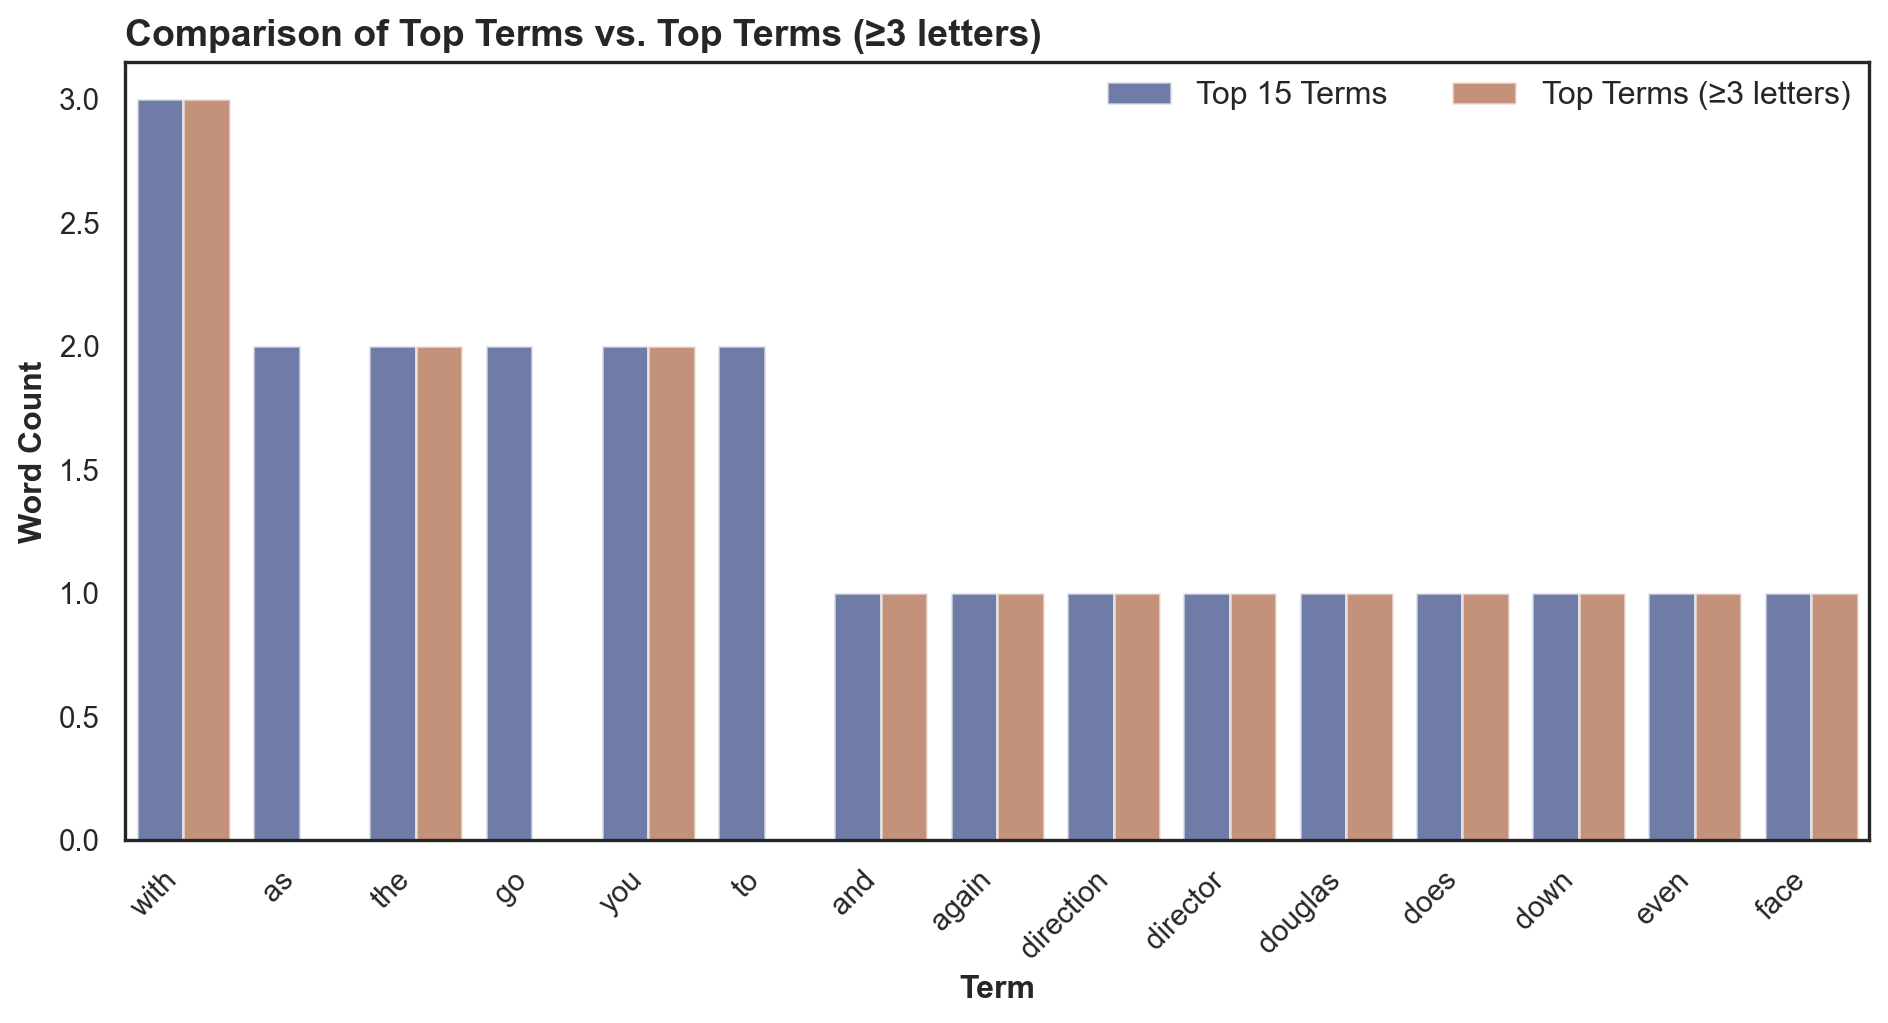

In [9]:
#| echo: false
#| eval: true
#| 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sum word counts across all sampled documents
term_frequencies = bow_df.sum(axis=0)

# Select top 15 terms
top_terms = term_frequencies.sort_values(ascending=False).head(15)

# Drop words below 3 letters for clarity
top_terms_3 = top_terms[top_terms.index.str.len() >= 3]

# ---------------------------------------------------------
# 1. Prepare data for grouped barplot
# ---------------------------------------------------------

df_plot = pd.DataFrame({
    "term": top_terms.index,
    "count_top15": top_terms.values,
    "count_top15_3": top_terms_3.reindex(top_terms.index, fill_value=0).values
})

df_melt = df_plot.melt(
    id_vars="term",
    value_vars=["count_top15", "count_top15_3"],
    var_name="category",
    value_name="count"
)

df_melt["category"] = df_melt["category"].map({
    "count_top15": "Top 15 Terms",
    "count_top15_3": "Top Terms (≥3 letters)"
})

# ---------------------------------------------------------
# 2. Global styling
# ---------------------------------------------------------

plt.rcParams["font.family"] = "Roboto"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

sns.set_theme(style="white")

# ---------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=df_melt,
    x="term",
    y="count",
    hue="category",
    palette=sns.color_palette("dark", n_colors=2),
    alpha=0.6 #
)

# Title: bold, left-aligned, 14 pt
plt.title("Comparison of Top Terms vs. Top Terms (≥3 letters)",
          fontsize=14, fontweight="bold", loc="left")

# Axis labels bold
plt.xlabel("Term", fontsize=12, fontweight="bold")
plt.ylabel("Word Count", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=11)

# Legend outside top-right
plt.legend(
    title="",
    fontsize=12,
    loc="upper right",           # anchor to top-right corner
    bbox_to_anchor=(1, 1),       # position inside plot
    ncol=2,                      # horizontal layout
    borderaxespad=0.2,           # slight padding
    frameon=False                # optional: remove legend box
)

plt.tight_layout()
plt.show()